# Matplotlib Controls and Common Plot Types

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

```{contents}
:local:
:depth: 2
```


```{index} plot controls
```
## Plot Controls and Methods

This section focuses on controlling the visible appearance of a figure and Axes.


```{index} subplots parameters
```
### `subplots()` Parameters



| Parameter | Type | Default | What It Controls | Example |
| --- | --- | --- | --- | --- |
| `nrows` | int | 1 | Number of subplot rows | `plt.subplots(2, 1)` |
| `ncols` | int | 1 | Number of subplot columns | `plt.subplots(1, 3)` |
| `figsize` | tuple | None | Figure size `(width, height)` in inches | `figsize=(8, 4)` |
| `dpi` | int | rcParams value | Resolution in dots per inch | `dpi=150` |
| `sharex` | bool or str | False | Share x-axis between subplots | `sharex=True` |
| `sharey` | bool or str | False | Share y-axis between subplots | `sharey='row'` |
| `squeeze` | bool | True | Return a scalar vs array of axes when possible | `squeeze=False` |

For a longer reference, see [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).


```{index} figure methods
```
### Figure-Level Controls

In contrast to `ax` methods, figure-level methods act on the **whole figure** rather than on a single axes. They are especially useful for overall sizing, layout, titles, and exporting.

| Method | What it sets |
|---|---|
| **`fig.suptitle('title')`** | Master title over all subplots |
| **`fig.tight_layout()`** | Auto-fix subplot spacing |
| `fig.set_size_inches(w, h)` | Figure size |
| `fig.savefig('file.png')` | Save to file (also `.pdf`, `.svg`, etc.) |
| `fig.set_dpi(150)` | Resolution |
| `fig.subplots_adjust(...)` | Manual spacing (`hspace`, `wspace`, `left`, `right`, ...) |
| `fig.colorbar(mappable, ax=ax)` | Add a colorbar tied to an axes |


```{index} axes methods
```
### Axes Formatting Methods

After creating a figure and axes, the next step is usually formatting. These methods do not change the underlying data; they control how the plot is labeled, styled, and displayed.

| Method | What it sets |
|---|---|
| **`ax.plot(x, y, 'r')`** | Plot data (format string: color + linestyle + marker) |
| **`ax.set_xlabel('label')`** | X-axis label |
| **`ax.set_ylabel('label')`** | Y-axis label |
| **`ax.set_title('title')`** | Title above the plot |
| **`ax.legend()`** | Add a legend to that axes |
| `ax.set_xlim(min, max)` | X-axis range |
| `ax.set_ylim(min, max)` | Y-axis range |
| `ax.grid(True)` | Toggle grid |


```{index} plot parameters, line width (linewidth)
```
### `ax.plot()` Parameters

| Parameter | Type | Default | What It Controls | Example |
| --- | --- | --- | --- | --- |
| `x`, `y` | array-like | — | Data to plot | `ax.plot(x, y)` |
| `color` | str or tuple | auto | Line color | `color='red'` |
| `linewidth` / `lw` | float | 1.5 | Thickness of the line | `lw=2` |
| `linestyle` / `ls` | str | `'-'` | Line style | `ls='--'` |
| `marker` | str | `None` | Marker shape at each data point | `marker='o'` |
| `markersize` / `ms` | float | 6 | Marker size | `ms=8` |
| `markerfacecolor` / `mfc` | str | auto | Fill color of markers | `mfc='white'` |
| `markeredgecolor` / `mec` | str | auto | Edge color of markers | `mec='black'` |
| `alpha` | float | 1.0 | Transparency (0 = invisible, 1 = opaque) | `alpha=0.7` |
| `label` | str | `None` | Legend label for the line | `label='Series A'` |
| `zorder` | float | auto | Drawing order (higher = on top) | `zorder=5` |

Common `linestyle` values: `'-'` (solid), `'--'` (dashed), `'-.'` (dash-dot), `':'` (dotted).  
Common `marker` values: `'o'` (circle), `'s'` (square), `'^'` (triangle), `'x'` (cross), `'+'` (plus), `'.'` (point).

For a full reference, see [matplotlib.axes.Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html).



```{index} styling charts
```
## Styling in Practice

```{index} rcParams, style sheet (plt.style.use)
```
### `rcParams`

matplotlib offers a range of pre-configured plotting styles. Setting the style can be used to easily give plots the general look that you want. To set the style, the syntax is:

```python
matplotlib.style.use(my_plot_style)
```

To check the aviaible style in the environment, use
```python
plt.style.available
```

Choose a style and see how `pt.rcParams` helps with styling.

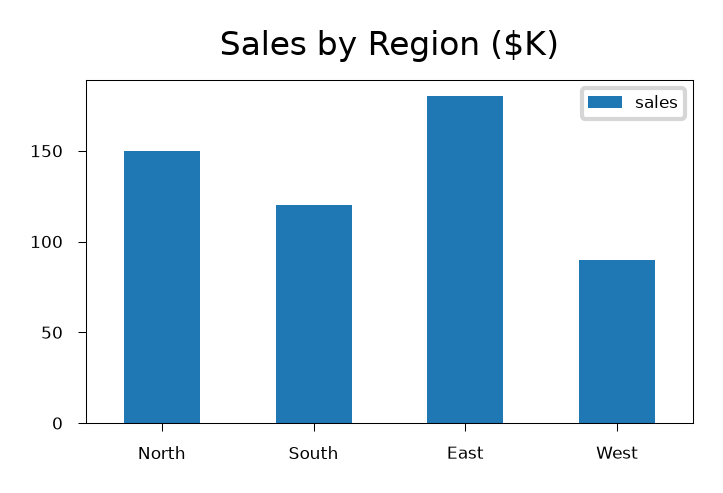

In [2]:
# plt.style.use("default")        ### reset to default style
# # plt.style.use("ggplot")
# plt.style.use("bmh")
# plt.style.use("classic")
# plt.style.use("seaborn-v0_8-muted")

%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.linewidth"] = 0.25  # set globally
plt.rcParams["xtick.major.width"] = 0.25  # set globally
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["ytick.major.size"] = 2

df_regions = pd.DataFrame({'sales': [150, 120, 180, 90]},
                          index=['North', 'South', 'East', 'West'])   ### quarterly sales in $K
df_regions.plot.bar(figsize=(2.5, 1.75), fontsize=4);
plt.title("Sales by Region ($K)", fontsize=8);
plt.legend(fontsize=4, loc="best", bbox_to_anchor=(1, 1));
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()

In [3]:
plt.rcParams["figure.dpi"] = 100

```{index} legend
```
### Legends for Axes



Legends are attached to an **axes** in the OO API. You typically supply `label=...` when plotting, then call `ax.legend()` to display the legend for that axes.


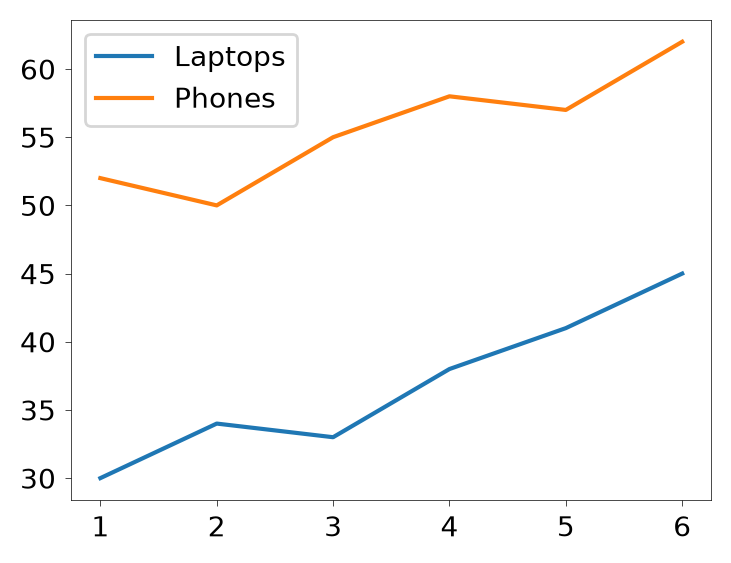

In [4]:
month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])          ### units sold
phones = np.array([52, 50, 55, 58, 57, 62])

fig = plt.figure(figsize=(4,3), dpi=100)

ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.plot(month, laptops, label="Laptops")   ### label= is what the legend shows
ax.plot(month, phones, label="Phones")
ax.legend()


If the legend overlaps the plotted data, pass a `loc=` argument to `ax.legend()` to move it.

Common values include string labels such as `'best'`, `'upper right'`, `'upper left'`, `'lower left'`, and `'lower right'`.


Text(0.5, 1.0, "loc='best'")

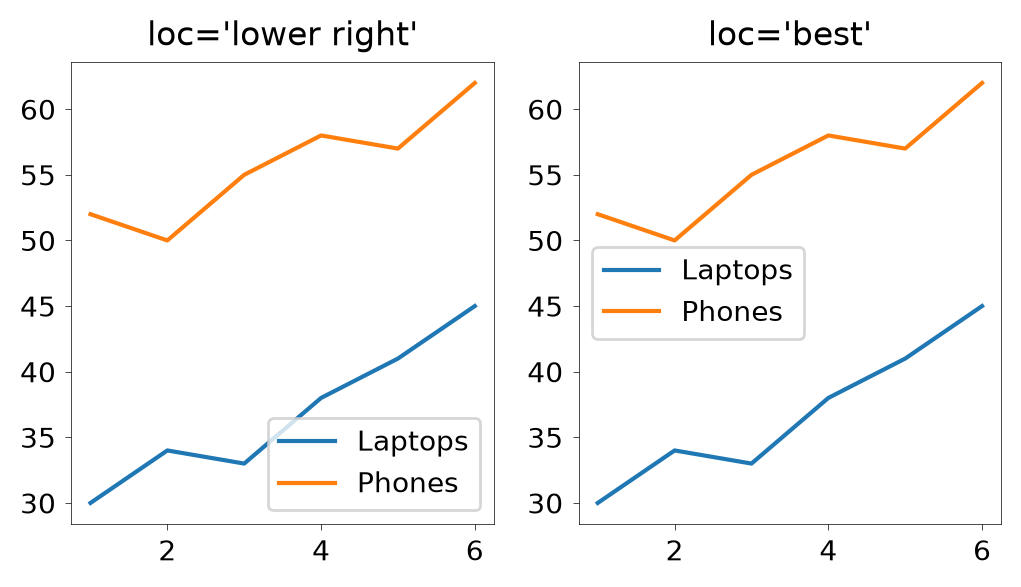

In [5]:
month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])          ### units sold
phones = np.array([52, 50, 55, 58, 57, 62])

fig, ax = plt.subplots(1, 2, figsize=(6,3), dpi=100)

ax[0].plot(month, laptops, label="Laptops")
ax[0].plot(month, phones, label="Phones")
ax[0].legend(loc='lower right')
ax[0].set_title("loc='lower right'")

ax[1].plot(month, laptops, label="Laptops")
ax[1].plot(month, phones, label="Phones")
ax[1].legend(loc='best')
ax[1].set_title("loc='best'")

```{index} axis range (set_xlim and set_ylim)
```
### Plot Range `set_xlim(), set_ylim()`

You can set axis ranges directly with `ax.set_xlim(...)` and `ax.set_ylim(...)`, or use `ax.axis('tight')` to fit the view closely around the data. 

In the example below, `axes[2]` is **zoomed in** on the promotion week: it shows only days 14 to 22 and sales between 30 and 80 ($K). That's why it looks different from the first two even though it plots the same data.

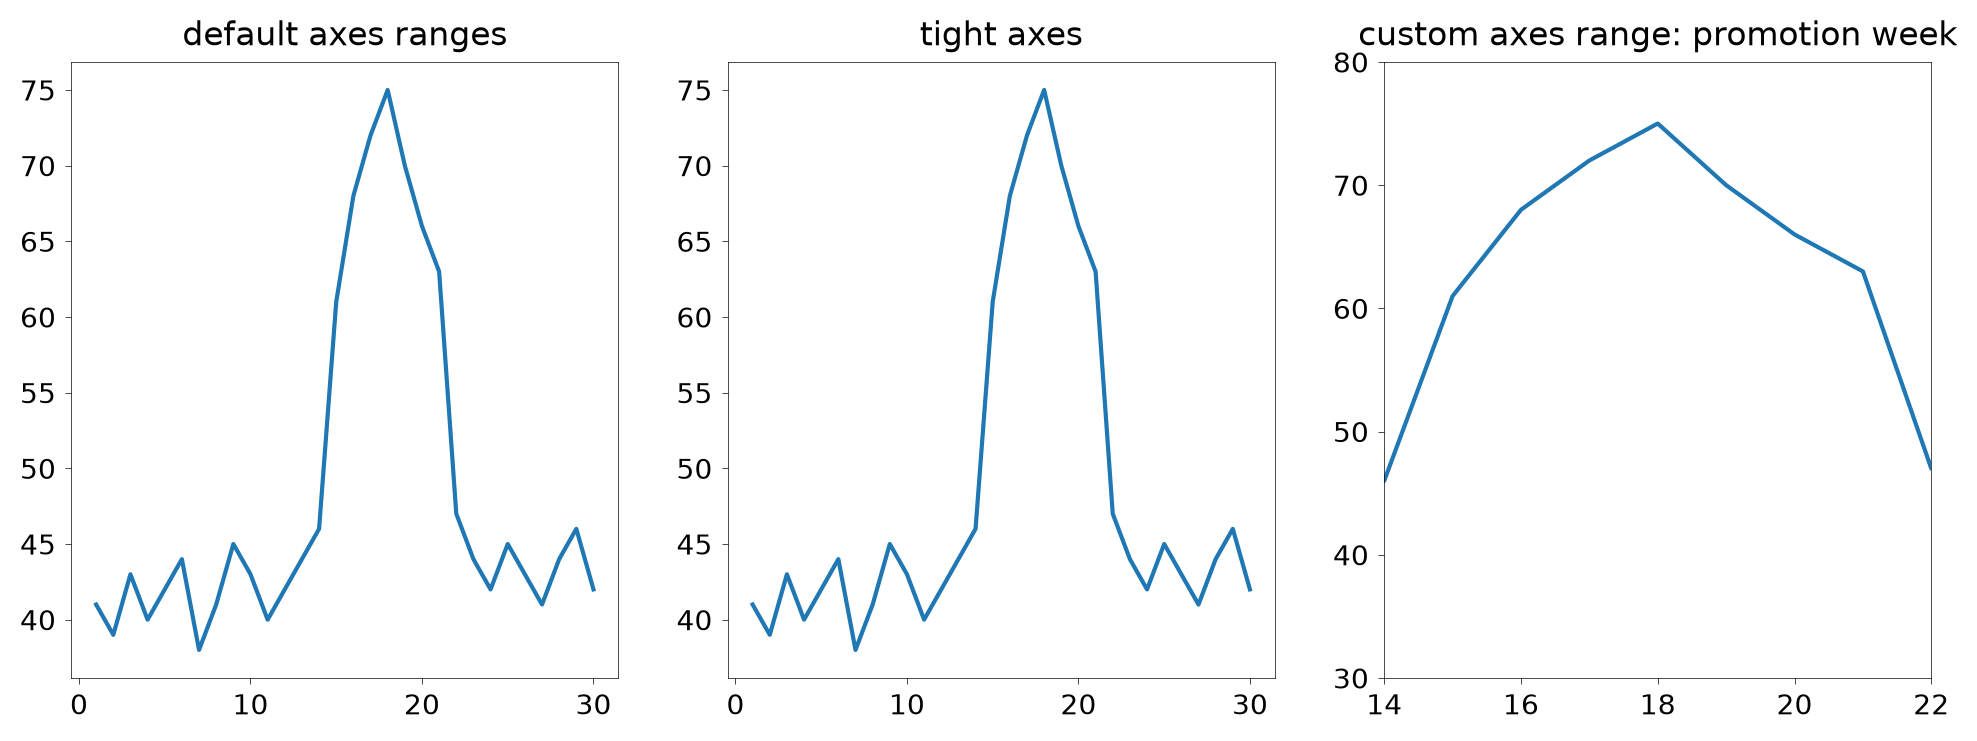

In [6]:
day = np.arange(1, 31)                  ### days in June
daily_sales = np.array([41, 39, 43, 40, 42, 44, 38, 41, 45, 43,
                        40, 42, 44, 46, 61, 68, 72, 75, 70, 66,
                        63, 47, 44, 42, 45, 43, 41, 44, 46, 42])   ### $K; promotion on days 15-21

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(day, daily_sales)
axes[0].set_title("default axes ranges")

axes[1].plot(day, daily_sales)
axes[1].axis('tight')
axes[1].set_title("tight axes")

axes[2].plot(day, daily_sales)
axes[2].set_ylim([30, 80])       # y-axis runs from 30 to 80
axes[2].set_xlim([14, 22])       # x-axis runs from day 14 to day 22
axes[2].set_title("custom axes range: promotion week");

In [7]:
### Exercise: Controlling Axis Ranges
#   1. Create month = np.arange(1, 13),
#      this_year = np.array([110, 104, 118, 121, 125, 119, 130, 128, 135, 150, 168, 190]), and
#      last_year = np.array([98, 95, 104, 108, 112, 110, 117, 115, 121, 133, 150, 171]).
#   2. Use fig, axes = plt.subplots(1, 2, figsize=(10, 4)).
#   3. On axes[0], plot month vs this_year and month vs last_year. Set title "Full Year".
#   4. On axes[1], plot the same data, then set:
#      - x-axis limits to [1, 6] using set_xlim
#      - y-axis limits to [80, 140] using set_ylim
#      Set title "First Half".
#   5. Call plt.tight_layout() at the end.
### Your code starts here.




### Your code ends here.

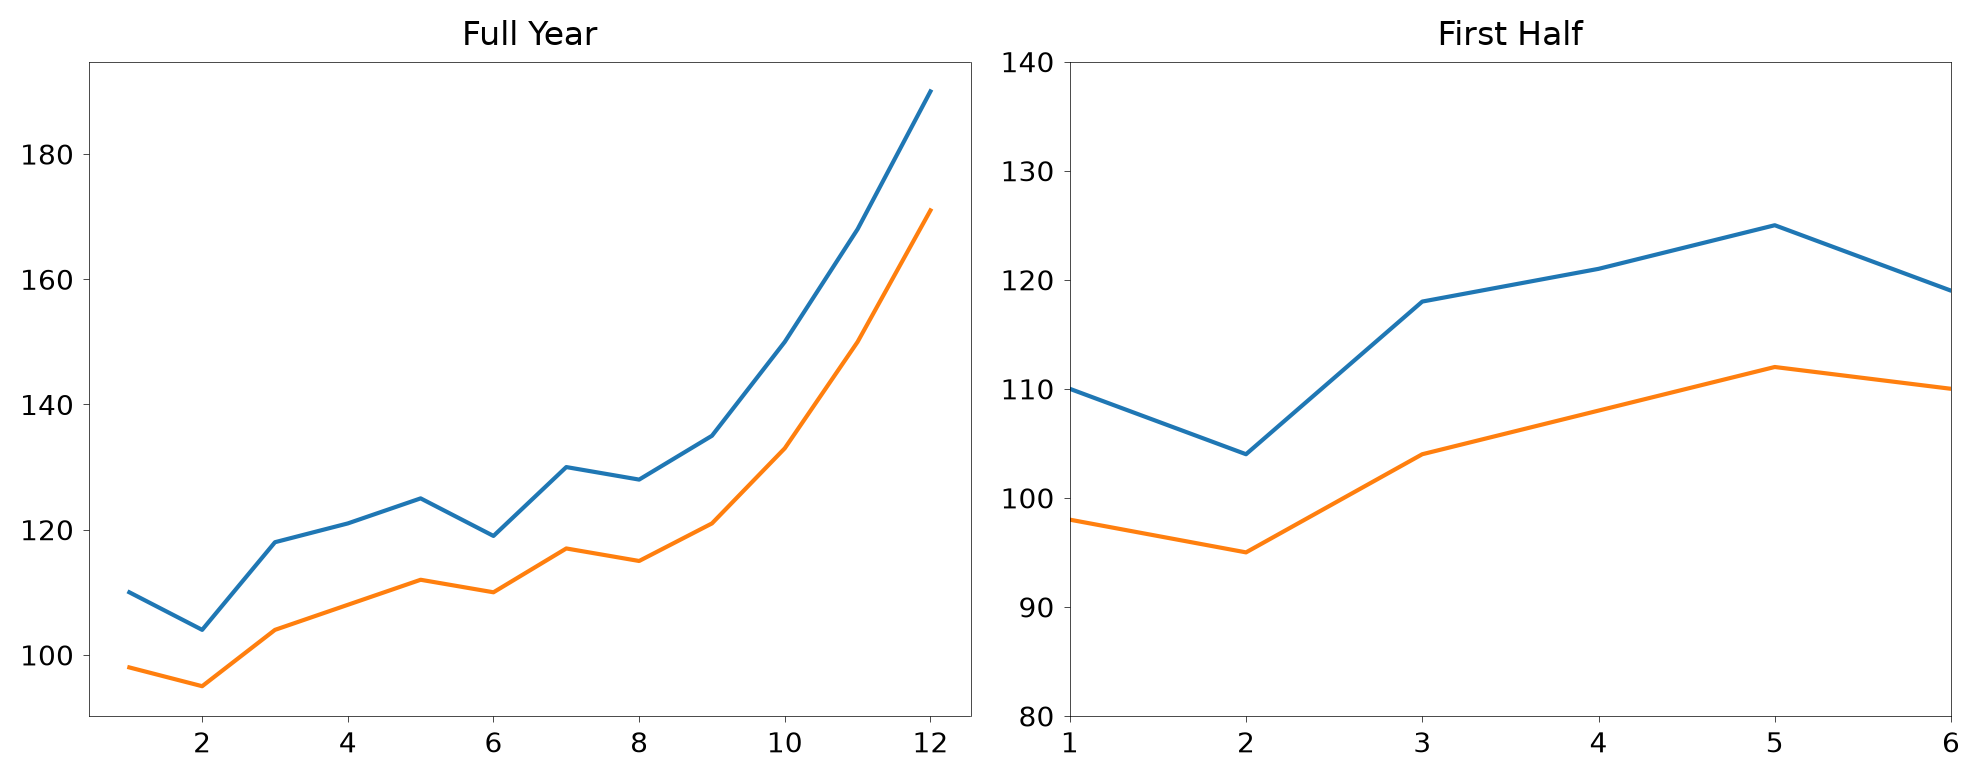

In [8]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 13)
this_year = np.array([110, 104, 118, 121, 125, 119, 130, 128, 135, 150, 168, 190])
last_year = np.array([98, 95, 104, 108, 112, 110, 117, 115, 121, 133, 150, 171])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(month, this_year)
axes[0].plot(month, last_year)
axes[0].set_title('Full Year')
axes[1].plot(month, this_year)
axes[1].plot(month, last_year)
axes[1].set_xlim(1, 6)
axes[1].set_ylim(80, 140)
axes[1].set_title('First Half')
plt.tight_layout()
plt.show()

```{index} color, line style
```
### Colors, Line Width and Style

Matplotlib gives you many options for customizing colors, line widths, and line styles.


```{index} format string
```
#### MATLAB-style format strings



Matplotlib supports short MATLAB-style format strings such as `'b.-'`, which combine color, line style, and marker style in one compact argument.


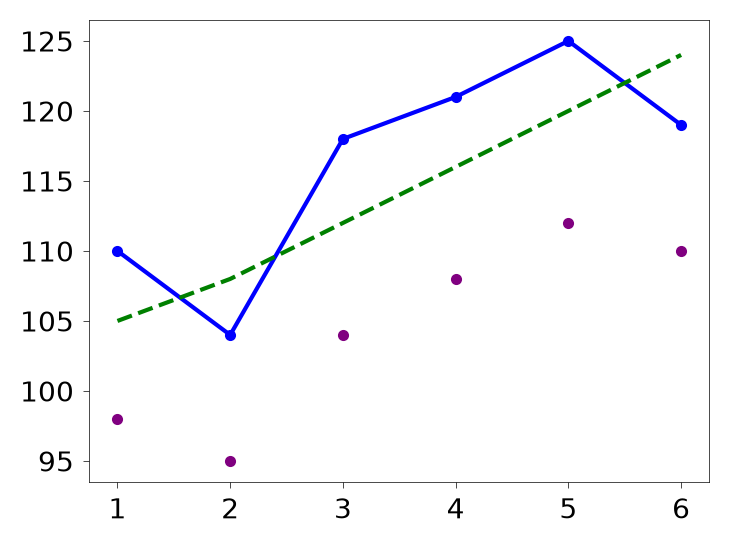

In [9]:
month = np.arange(1, 7)
actual = np.array([110, 104, 118, 121, 125, 119])      ### revenue in $K
budget = np.array([105, 108, 112, 116, 120, 124])
last_year = np.array([98, 95, 104, 108, 112, 110])

### MATLAB style line color and style
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(month, actual, 'b.-')         # blue line with dots
ax.plot(month, budget, 'g--')         # green dashed line

### .plot() parameters can also be specified in a more explicit way
# ax.scatter(month, last_year, color='purple', marker='.', linestyle='--')   # more explicit
ax.scatter(month, last_year, color='purple', marker='.')   # scatter does not have linestyle, so we omit it here

In [10]:
### Exercise: MATLAB-Style Color and Line Formatting
#   1. Create month = np.arange(1, 7),
#      store_a = np.array([62, 58, 66, 70, 73, 69]), and
#      store_b = np.array([48, 51, 47, 55, 58, 60]).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Plot month vs store_a using 'b.-' (blue line with dots).
#   4. Plot month vs store_b using 'r--' (red dashed line).
#   5. Set the title to "Store A vs Store B".
### Your code starts here.




### Your code ends here.

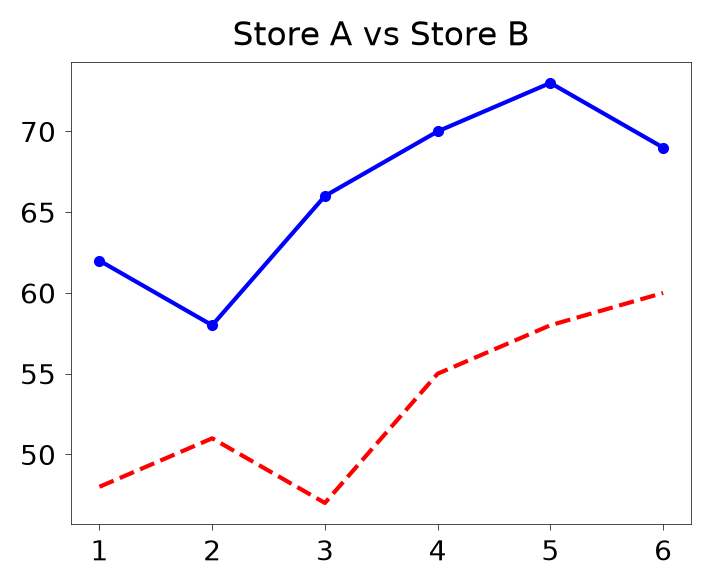

In [11]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
store_a = np.array([62, 58, 66, 70, 73, 69])
store_b = np.array([48, 51, 47, 55, 58, 60])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, store_a, 'b.-')
ax.plot(month, store_b, 'r--')
ax.set_title('Store A vs Store B')
plt.show()


```{index} color (hex code), alpha (transparency)
```
#### The `color=` Parameter



You can also define colors by name or by RGB hex code, and control transparency with `alpha`.


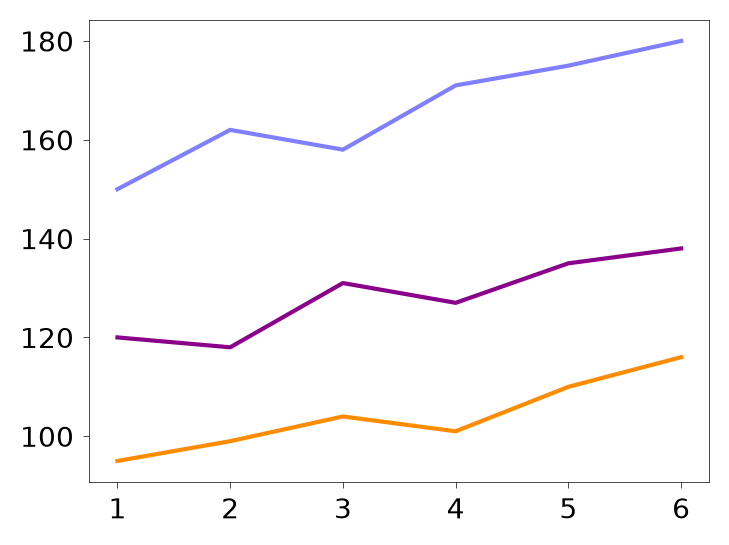

In [12]:
month = np.arange(1, 7)
north = np.array([150, 162, 158, 171, 175, 180])     ### revenue in $K
south = np.array([120, 118, 131, 127, 135, 138])
east = np.array([95, 99, 104, 101, 110, 116])

fig, ax = plt.subplots(figsize=(4,3), dpi=100)

ax.plot(month, north, color="blue", alpha=0.5)   ### half-transparent
ax.plot(month, south, color="#8B008B")           ### RGB hex code
ax.plot(month, east, color="#FF8C00")            ### RGB hex code

In [13]:
### Exercise: Colors with the color= Parameter and Alpha
#   1. Create month = np.arange(1, 7),
#      laptops = np.array([30, 34, 33, 38, 41, 45]),
#      phones = np.array([52, 50, 55, 58, 57, 62]), and
#      tablets = np.array([18, 20, 19, 23, 22, 25]).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Plot month vs laptops with color="blue" and alpha=0.3.
#   4. Plot month vs phones with color="#228B22" (forest green) and alpha=0.7.
#   5. Plot month vs tablets with color="tomato" and alpha=1.0.
#   6. Set the title to "Units Sold by Product".
### Your code starts here.




### Your code ends here.

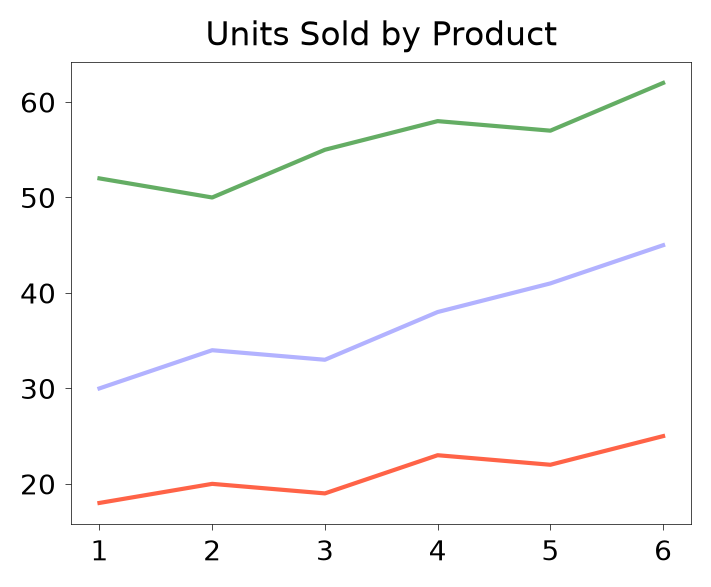

In [14]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])
phones = np.array([52, 50, 55, 58, 57, 62])
tablets = np.array([18, 20, 19, 23, 22, 25])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, laptops, color='blue', alpha=0.3)
ax.plot(month, phones, color='#228B22', alpha=0.7)
ax.plot(month, tablets, color='tomato', alpha=1.0)
ax.set_title('Units Sold by Product')
plt.show()


```{index} marker, line width
```
#### Line and marker styles



To change line width, use `linewidth` or `lw`. To change line style, use `linestyle` or `ls`. Marker shape, size, and colors can also be customized.


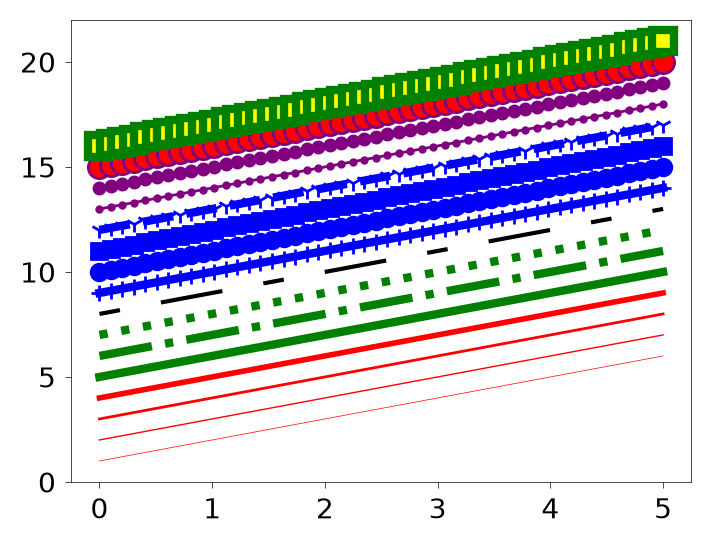

In [15]:
x = np.linspace(0, 5, 50)               ### simple numbers: this cell is a catalog of styles, not data

fig, ax = plt.subplots(figsize=(4,3))

ax.plot(x, x+1, color="red", linewidth=0.25)
ax.plot(x, x+2, color="red", linewidth=0.50)
ax.plot(x, x+3, color="red", lw=1.00)
ax.plot(x, x+4, color="red", lw=2.00)

### possible linestyle options ‘--‘, ‘–’, ‘-.’, ‘:’, or ‘None’ (the default is '-'). 
ax.plot(x, x+5, color="green", lw=3, linestyle='-')
ax.plot(x, x+6, color="green", lw=3, ls='-.')
ax.plot(x, x+7, color="green", lw=3, ls=':')

### custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10])        ### format: line length, space length, ...

### possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="blue", lw=3, ls='-', marker='+')
ax.plot(x, x+10, color="blue", lw=3, ls='--', marker='o')
ax.plot(x, x+11, color="blue", lw=3, ls='-', marker='s')
ax.plot(x, x+12, color="blue", lw=3, ls='--', marker='1')

### marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8, 
        markerfacecolor="yellow", markeredgewidth=3, markeredgecolor="green");

In [16]:
### Exercise: Line Width, Style, and Markers
#   1. Create month = np.arange(1, 7),
#      actual = np.array([110, 104, 118, 121, 125, 119]),
#      budget = np.array([105, 108, 112, 116, 120, 124]), and
#      last_year = np.array([98, 95, 104, 108, 112, 110]).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Plot month vs actual: color='red', lw=2, ls='-', marker='o'.
#   4. Plot month vs budget: color='green', lw=1, ls='--', marker='s'.
#   5. Plot month vs last_year: color='blue', lw=3, ls=':', marker='^',
#      markersize=8, markerfacecolor='yellow'.
#   6. Set the title to "Actual, Budget, and Last Year".
### Your code starts here.




### Your code ends here.

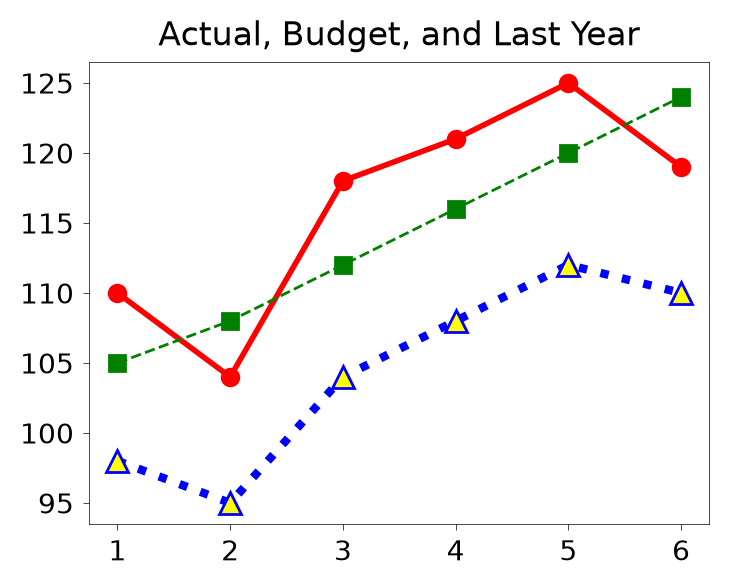

In [17]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
actual = np.array([110, 104, 118, 121, 125, 119])
budget = np.array([105, 108, 112, 116, 120, 124])
last_year = np.array([98, 95, 104, 108, 112, 110])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, actual, color='red', lw=2, ls='-', marker='o')
ax.plot(month, budget, color='green', lw=1, ls='--', marker='s')
ax.plot(month, last_year, color='blue', lw=3, ls=':', marker='^', markersize=8, markerfacecolor='yellow')
ax.set_title('Actual, Budget, and Last Year')
plt.show()

```{index} plot types
```
## Common Plot Types

So far we have used line plots to introduce Matplotlib. Below are a few common plot types, shown in the OO style so the examples stay consistent with the rest of the notebook.



```{index} scatter plot
```
### Scatter Plot

A **scatter plot** displays individual data points as dots on a two-dimensional plane, with one variable on the x-axis and another on the y-axis. Each dot represents a single observation. Scatter plots are useful for visualizing the relationship or correlation between two continuous variables, and for identifying patterns, clusters, or outliers in the data.


Text(0, 0.5, 'Units Sold per Week')

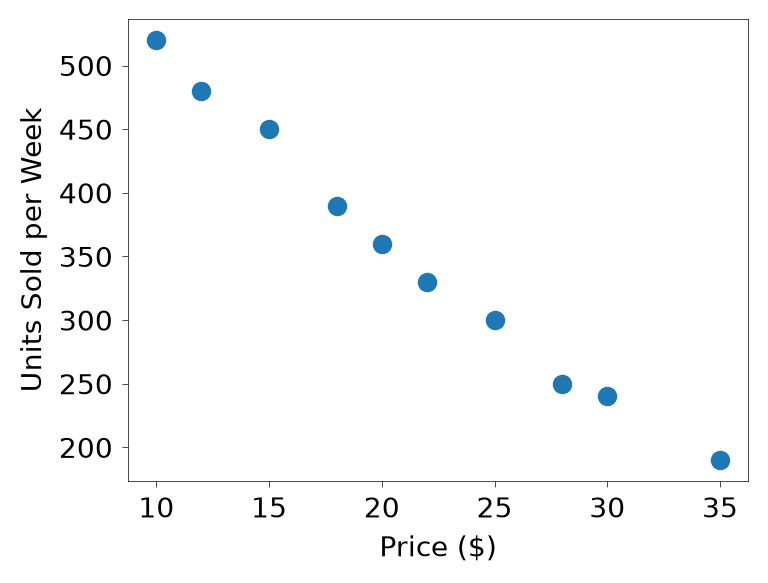

In [18]:
price = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 35])     ### product price in $
units = np.array([520, 480, 450, 390, 360, 330, 300, 250, 240, 190])   ### units sold per week

fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(price, units)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Units Sold per Week')


```{index} bar plot
```
### Bar Plot

A **bar plot** displays categorical data as rectangular bars, where the height (or length) of each bar is proportional to the value it represents. The x-axis typically shows the categories and the y-axis shows the corresponding values. Bar plots are useful for comparing quantities across distinct groups or categories.


Text(0.5, 1.0, 'Sales by Department ($K)')

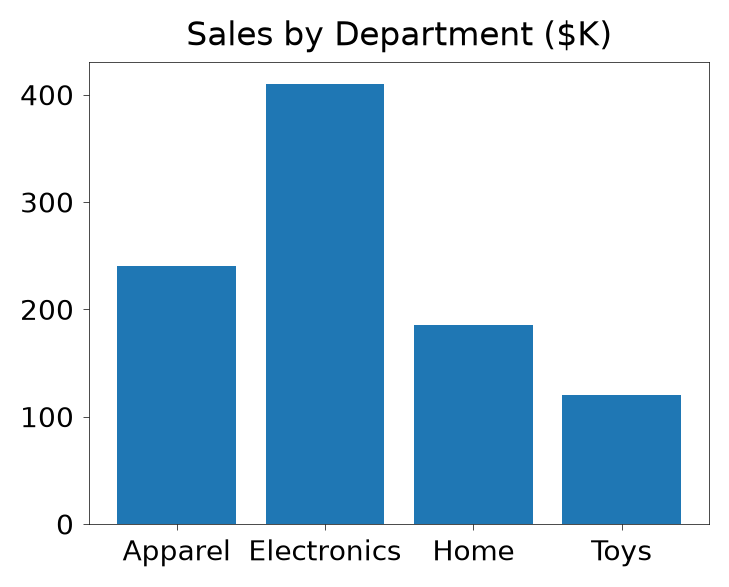

In [19]:
departments = ['Apparel', 'Electronics', 'Home', 'Toys']
sales = [240, 410, 185, 120]                   ### quarterly sales in $K

fig, ax = plt.subplots(figsize=(4,3))
ax.bar(departments, sales)
ax.set_title('Sales by Department ($K)')


```{index} histogram, bin
```
### Histogram

A **histogram** displays the distribution of a continuous variable by dividing the data into bins (intervals) and counting how many values fall into each bin. The x-axis represents the value ranges, and the y-axis represents the frequency (count) of observations in each bin. Histograms are useful for visualizing the shape of a distribution — whether it is symmetric, skewed, or has multiple peaks.


Text(0, 0.5, 'Number of Orders')

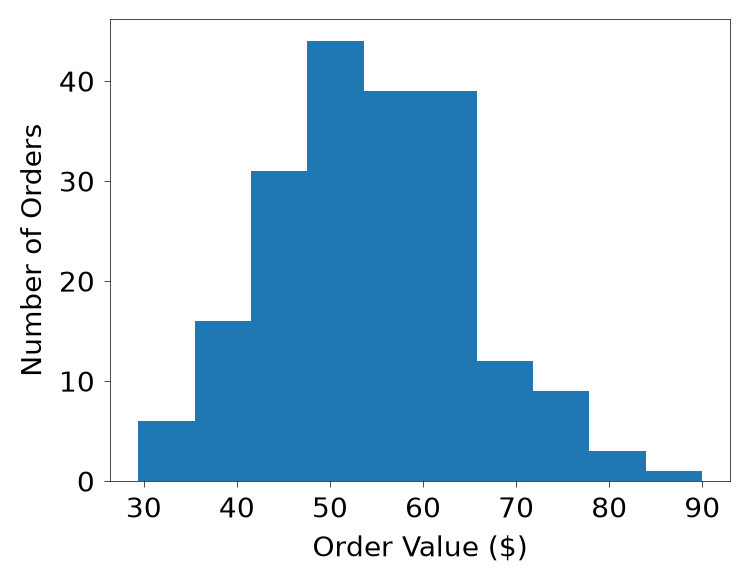

In [20]:
rng = np.random.default_rng(42)                        ### fixed seed: same numbers every run
order_values = rng.normal(loc=55, scale=12, size=200)  ### 200 online orders, in $

fig, ax = plt.subplots(figsize=(4,3))
ax.hist(order_values)
ax.set_xlabel('Order Value ($)')
ax.set_ylabel('Number of Orders')


```{index} boxplot, interquartile range, outlier
```
### Boxplot

A **boxplot** (also called a box-and-whisker plot) summarizes the distribution of a dataset using five key statistics: 

- the minimum, 
- first quartile (Q1), 
- median, 
- third quartile (Q3), and 
- maximum. 

Also:
- The box: The box spans from Q1 to Q3 (the **interquartile** range, IQR)
- The line: the line inside the box marks the **median**. 
- The whiskers: The whiskers extend to the last data points within **1.5 × IQR** from Q1 and Q3. 
- Points/circles beyond the whiskers are plotted individually as **outliers**. 

Boxplots are useful for comparing distributions across multiple groups.

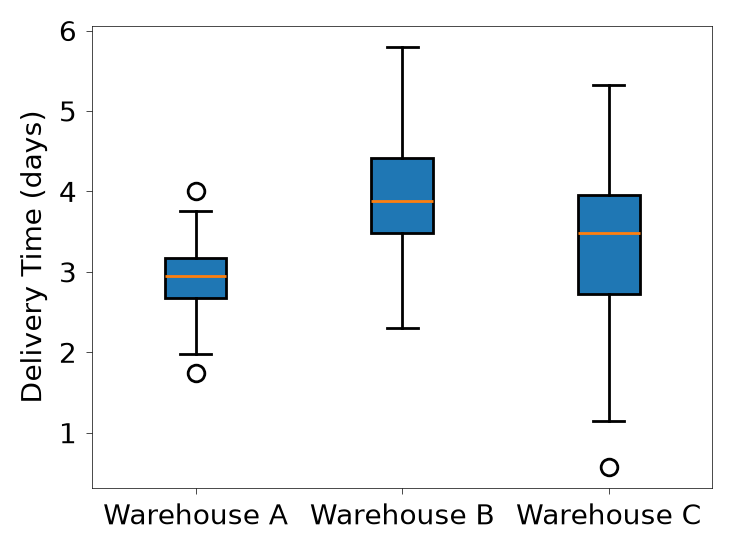

In [21]:
rng = np.random.default_rng(7)                         ### fixed seed: same numbers every run
### list comprehension to create delivery times (days) for three warehouses
delivery_days = [rng.normal(mean, sd, 100) for mean, sd in [(3.0, 0.5), (4.0, 0.8), (3.5, 0.9)]]

fig, ax = plt.subplots(figsize=(4,3))

### rectangular box plot
ax.boxplot(delivery_days, patch_artist=True)
ax.set_xticks([1, 2, 3], ['Warehouse A', 'Warehouse B', 'Warehouse C'])
ax.set_ylabel('Delivery Time (days)');

In [22]:
### Exercise: Visualizing Sales Data with Different Plot Types
#   The following data represent quarterly sales figures ($K) for four products
#   and daily website visits over 100 days.
#
#   products = ['Laptop', 'Phone', 'Tablet', 'Watch']
#   sales    = [320, 580, 140, 210]
#   visits   = np.random.default_rng(0).normal(loc=500, scale=80, size=100)
#
#   1. Create a figure with two side-by-side subplots: fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#   2. On ax1, draw a bar chart of products vs. sales.
#      Set the title to "Quarterly Product Sales", x-label "Product", y-label "Sales ($K)".
#   3. On ax2, draw a histogram of visits using ax2.hist(visits, bins=15), 
#      color='orange', edgecolor='white', and alpha=0.7.
#      Set the title to "Daily Website Visits", x-label "Visits", y-label "Frequency".
#   4. Call plt.tight_layout() before displaying.
### Your code starts here.




### Your code ends here.

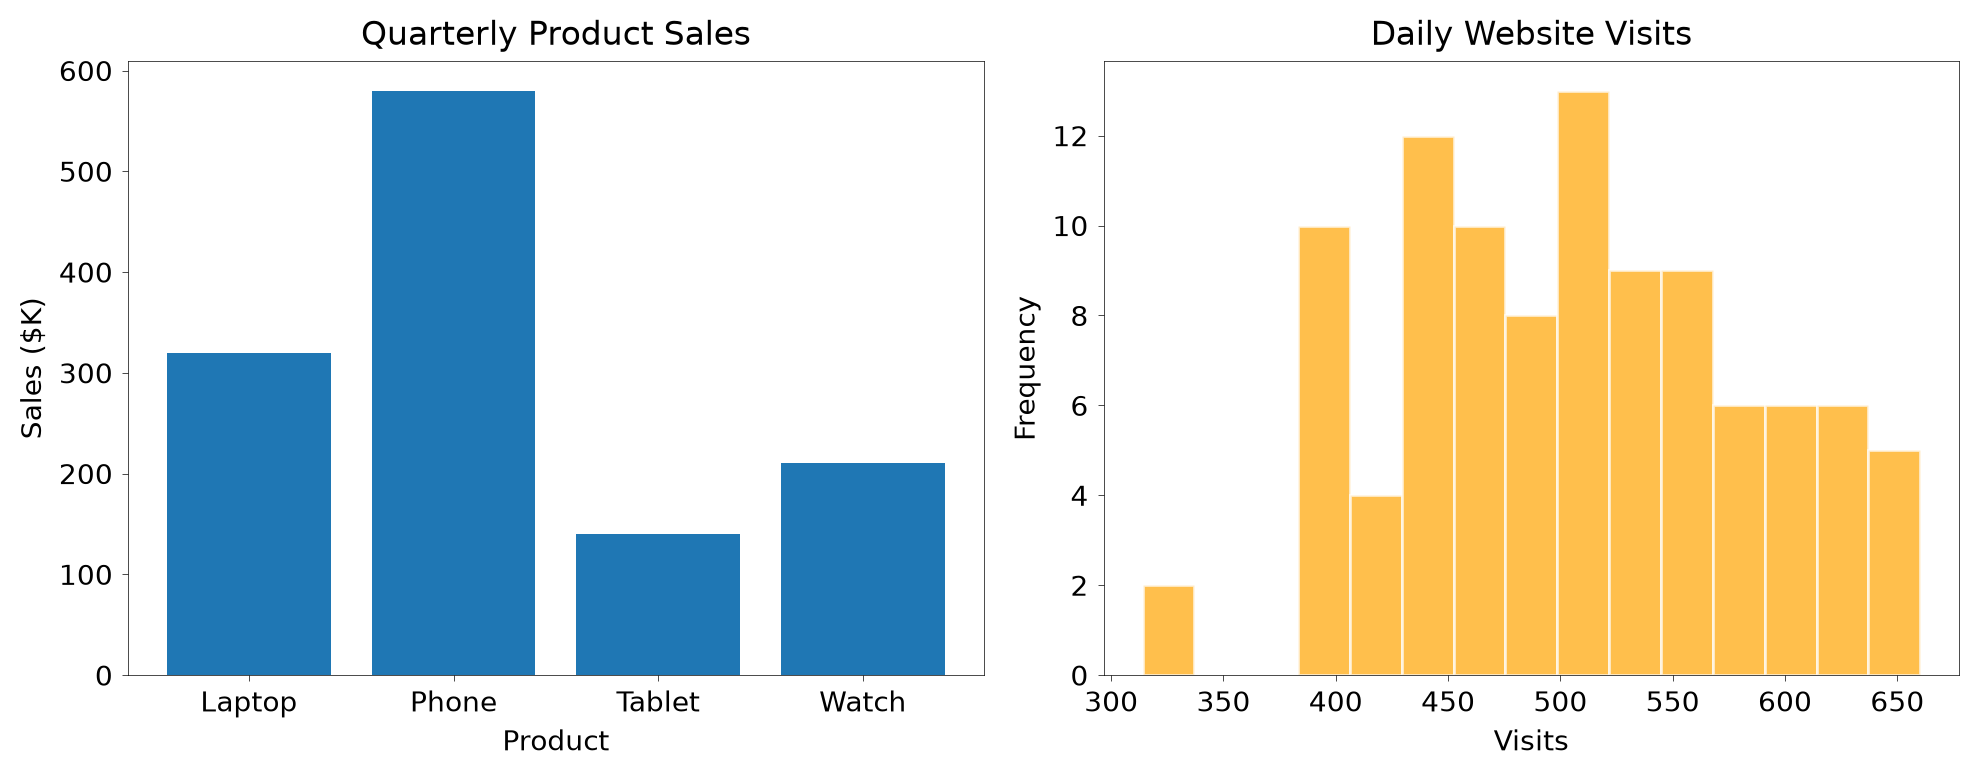

In [23]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
products = ['Laptop', 'Phone', 'Tablet', 'Watch']
sales = [320, 580, 140, 210]
visits = rng.normal(loc=500, scale=80, size=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(products, sales)
ax1.set_title('Quarterly Product Sales')
ax1.set_xlabel('Product')
ax1.set_ylabel('Sales ($K)')
ax2.hist(visits, bins=15, color='orange', edgecolor='white', alpha=0.7)
ax2.set_title('Daily Website Visits')
ax2.set_xlabel('Visits')
ax2.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Summary

- Figure-level methods (`fig.suptitle()`, `fig.tight_layout()`, `fig.savefig()`) act on the whole figure; axes methods (`ax.set_title()`, `ax.set_xlim()`, `ax.legend()`, `ax.grid()`) act on one chart.
- `rcParams` and style sheets (`plt.style.use()`) change the defaults for every chart drawn afterward.
- Give each series a `label=` and call `ax.legend()`; use `loc=` to move the legend off the data.
- `ax.set_xlim()` and `ax.set_ylim()` zoom in on part of the data or start an axis at zero.
- Colors (names or hex codes), `alpha`, line style, line width, and markers make series easy to tell apart. A format string such as `'r--'` sets several of these at once.
- Match the plot type to the question: a line plot for a trend, a bar plot for comparing categories, a scatter plot for a relationship, and a histogram or boxplot for a distribution.

A practical way to choose among the main Matplotlib workflows is:

- Use `plt.plot()` for quick, one-off exploration.
- Use `plt.subplots()` for most plotting tasks.
- Use `fig.add_axes()` when you need manual placement or inset axes.

## Further Reading

- [Customizing Matplotlib with style sheets and rcParams](https://matplotlib.org/stable/users/explain/customizing.html): every default you can change, and how to make your own style.
- [Plot types](https://matplotlib.org/stable/plot_types/index.html): a one-page overview of the chart types Matplotlib can draw.
- [Examples gallery](https://matplotlib.org/stable/gallery/index.html): hundreds of charts with the code that made them.